# 10. Q 적응 전략 성능 비교 — Q Adaptive Strategy Comparison

## 비교 전략 (6종 BL + 벤치마크 2종)

| 전략 | 설명 | 핵심 아이디어 |
|------|------|---------------|
| **Fixed-Q** | Q = Q_OPTIMAL 항상 고정 | 기준선 |
| **Regime3** | 저→Q_OPTIMAL / 중→×0.5 / 고→0 | 현재 08 방식 |
| **Q_lambda** | Q = Q_OPTIMAL × clip(λ/λ_mean, 0.1, 3.0) | 위험회피계수로 연속 스케일링 |
| **Regime+λ** | 고→0 (하드스탑) / 나머지→Q_OPTIMAL × clip(λ/λ_mean, 0.1, 3.0) | 하드스탑 + λ 미세조정 |
| **GARCH_conf** | Q = Q_OPTIMAL × GARCH예측신뢰도 | GARCH 정확도에 비례 |
| **π_ratio** | Q = Q_OPTIMAL × clip(\|P·π_t\| / 기준스프레드, 0.1, 3.0) | CAPM 스프레드 비율 고정 |
| **CAPM** | BL 없음, π로만 최적화 | 벤치마크 |
| **SPY** | S&P 500 지수 | 시장 벤치마크 |

## 의존성

```
04_VolatilityPrediction → vol_predicted.csv
06_Q_Sensitivity        → q_sensitivity_stats.csv  (Q_OPTIMAL 자동 로드)
```

## 파라미터

| 파라미터 | 값 | 설명 |
|---------|-----|------|
| `TRAIN_WINDOW` | 60 | 학습 윈도우 (월) |
| `TAU` | 0.1 | BL 스케일 파라미터 |
| `PCT_GROUP` | 0.30 | 저위험/고위험 분류 비율 |
| `LAM_MEAN` | 2.5 | Q_lambda 기준 위험회피계수 |
| `Q_MID_SCALE` | 0.5 | Regime3 중간 레짐 Q 배율 |
| `CONF_WINDOW` | 12 | GARCH 신뢰도 롤링 윈도우 (월) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
from bl_utils import *  # 공통 BL/Q/성과 유틸리티

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '10_Q_Adaptive_Comparison'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 고정 파라미터 ────────────────────────────────────────────
TRAIN_WINDOW = 60
TAU          = 0.1
PCT_GROUP    = 0.30
START_PRED   = '2011-01-01'
LAM_MEAN     = 2.5
Q_MID_SCALE  = 0.5
CONF_WINDOW  = 12

# ── 05번 최적 Q 자동 로드 ─────────────────────────────────────
STATS_05 = BASE_DIR / 'outputs' / '06_Q_Sensitivity' / 'q_sensitivity_stats.csv'
if STATS_05.exists():
    _s = pd.read_csv(STATS_05, index_col='label')
    _s = _s.drop(index=['CAPM', 'SPY'], errors='ignore')
    Q_OPTIMAL = float(_s['sharpe'].idxmax().split('=')[1])
    print(f'05 GARCH 최적 Q 로드 → Q_OPTIMAL = {Q_OPTIMAL}')
else:
    Q_OPTIMAL = 0.003
    print(f'05 결과 없음 → 기본값: Q_OPTIMAL = {Q_OPTIMAL}')

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

ret_pivot  = panel['ret_1m'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

PRED_PATH = DATA_DIR / 'vol_predicted.csv'
assert PRED_PATH.exists(), '05_VolatilityPrediction.ipynb 먼저 실행하세요'
vol_pred_pivot = (pd.read_csv(PRED_PATH, parse_dates=['date'])
                    .set_index(['date', 'ticker'])['vol_pred']
                    .unstack('ticker'))

print(f'패널: {panel.shape}')
print(f'기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'GARCH vol: {vol_pred_pivot.shape}')

05 GARCH 최적 Q 로드 → Q_OPTIMAL = 0.003
패널: (108135, 11)
기간: 2011-01-31 ~ 2025-12-31 (180개월)
GARCH vol: (180, 610)


# BL 함수 + Q 산출 함수

| 함수 | 전략 |
|------|------|
| `q_lambda(lam, q_base)` | Q_lambda, Regime+λ |
| `q_garch_conf(date, q_base)` | GARCH_conf |
| `q_pi_ratio(P, pi, q_base, ref)` | π_ratio |

# 사전 계산: 레짐 시계열 + GARCH 신뢰도

**레짐**: SPY 12개월 롤링 변동성 × expanding 분위수 (look-ahead bias 방지)

**GARCH 신뢰도**:
1. 각 시점 t에서 GARCH 예측 vol vs 실현 vol(vol_21d)의 MAPE 계산
2. 12개월 롤링 평균으로 스무딩
3. Expanding 분위수로 [0.3, 1.0] 정규화
   - GARCH가 정확할 때(MAPE 낮음) → 신뢰도 1.0 → Q 크게
   - GARCH가 틀릴 때(MAPE 높음) → 신뢰도 0.3 → Q 작게

레짐 분포:
중간      96
고변동성    60
저변동성    24

GARCH 신뢰도 (정규화):  평균=0.725  최소=0.300  최대=1.000


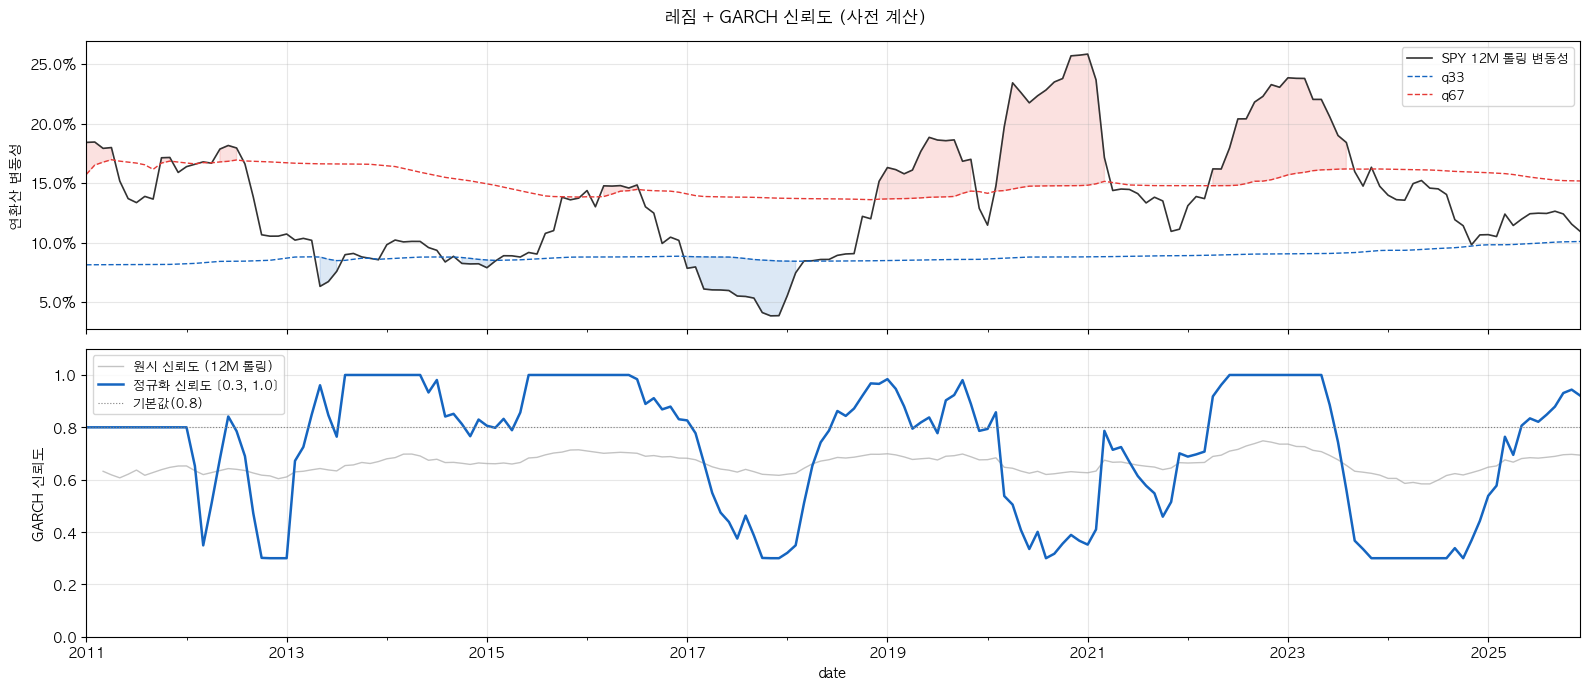

In [3]:
# ── 레짐 시계열 ───────────────────────────────────────────────
spy_roll_vol = spy_series.rolling(12).std() * np.sqrt(12)
q33_exp      = spy_roll_vol.expanding(min_periods=24).quantile(0.33)
q67_exp      = spy_roll_vol.expanding(min_periods=24).quantile(0.67)

spy_roll_pred = spy_roll_vol.reindex(pred_dates)
q33_pred      = q33_exp.reindex(pred_dates)
q67_pred      = q67_exp.reindex(pred_dates)

regime_series = pd.Series('중간', index=pred_dates)
regime_series[spy_roll_pred <= q33_pred] = '저변동성'
regime_series[spy_roll_pred >= q67_pred] = '고변동성'

print('레짐 분포:')
print(regime_series.value_counts().to_string())

# ── GARCH 신뢰도 사전 계산 ────────────────────────────────────
# 각 시점에서 GARCH 예측 vol과 실현 vol(vol_21d)의 MAPE로 신뢰도 계산
garch_rel_log = {}
for date in pred_dates:
    if date not in vol_pred_pivot.index:
        continue
    try:
        month_data = panel.xs(date, level='date')
        garch_vol  = vol_pred_pivot.loc[date].reindex(month_data.index)
        actual_vol = month_data['vol_21d']
        common     = garch_vol.dropna().index.intersection(actual_vol.dropna().index)
        if len(common) < 10:
            continue
        mape = (abs(garch_vol[common] - actual_vol[common])
                / actual_vol[common].clip(lower=0.001))
        garch_rel_log[date] = 1.0 - mape.clip(0, 1).mean()
    except Exception:
        pass

garch_rel_ts     = pd.Series(garch_rel_log).sort_index()
garch_rel_smooth = garch_rel_ts.rolling(CONF_WINDOW, min_periods=3).mean()

# Expanding 분위수 정규화 → [0.3, 1.0]  (look-ahead bias 없음)
q10   = garch_rel_smooth.expanding(min_periods=CONF_WINDOW).quantile(0.10)
q90   = garch_rel_smooth.expanding(min_periods=CONF_WINDOW).quantile(0.90)
denom = (q90 - q10).clip(lower=0.01)
garch_conf_norm  = ((garch_rel_smooth - q10) / denom).clip(0, 1) * 0.7 + 0.3
garch_conf_norm  = garch_conf_norm.reindex(pred_dates).ffill().fillna(0.8)

print(f'\nGARCH 신뢰도 (정규화):  평균={garch_conf_norm.mean():.3f}  '
      f'최소={garch_conf_norm.min():.3f}  최대={garch_conf_norm.max():.3f}')

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle('레짐 + GARCH 신뢰도 (사전 계산)', fontsize=12, fontweight='bold')

ax = axes[0]
spy_roll_pred.plot(ax=ax, color='#333', linewidth=1.2, label='SPY 12M 롤링 변동성')
q33_pred.plot(ax=ax, color='#1565C0', linestyle='--', linewidth=1.0, label='q33')
q67_pred.plot(ax=ax, color='#E53935', linestyle='--', linewidth=1.0, label='q67')
ax.fill_between(pred_dates,
                spy_roll_pred.where(spy_roll_pred >= q67_pred), q67_pred,
                alpha=0.15, color='#E53935')
ax.fill_between(pred_dates,
                spy_roll_pred.where(spy_roll_pred <= q33_pred), q33_pred,
                alpha=0.15, color='#1565C0')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('연환산 변동성')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
garch_rel_smooth.reindex(pred_dates).plot(
    ax=ax, color='#aaa', linewidth=1.0, alpha=0.7, label='원시 신뢰도 (12M 롤링)')
garch_conf_norm.plot(
    ax=ax, color='#1565C0', linewidth=1.8, label='정규화 신뢰도 [0.3, 1.0]')
ax.axhline(0.8, color='gray', linestyle=':', linewidth=0.8, label='기본값(0.8)')
ax.set_ylabel('GARCH 신뢰도')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'regime_garch_conf.png', dpi=150, bbox_inches='tight')
plt.show()

# Walk-forward 백테스트 — 6 전략 동시 계산

Sigma, π, P, Ω를 한 번만 계산하고 전략별로 Q 값만 바꿔 적용.  
공정한 비교를 위해 동일한 루프에서 모든 전략을 처리한다.

In [4]:
STRAT_NAMES = ['Fixed-Q', 'Regime3', 'Q_lambda', 'Regime+λ',
               'GARCH_conf', 'π_ratio', 'CAPM', 'SPY']
records     = {s: [] for s in STRAT_NAMES}
q_log       = []

# Regime3 Q 매핑
REGIME3_MAP = {
    '저변동성': Q_OPTIMAL,
    '중간':     Q_OPTIMAL * Q_MID_SCALE,
    '고변동성': 0.0,
}

# π_ratio 기준 스프레드: expanding 중앙값으로 실시간 추적 (look-ahead bias 없음)
pi_spread_history = []

print(f'Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'전략: {STRAT_NAMES}\n')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')

    try:
        if pred_date not in vol_pred_pivot.index:
            continue

        month_base = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_base) < 30:
            continue

        # GARCH vol 주입
        month_df = month_base.copy()
        month_df['vol_use'] = vol_pred_pivot.loc[pred_date].reindex(month_df.index)
        month_df = month_df.dropna(subset=['vol_use'])
        if len(month_df) < 20:
            continue

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        spy_excess  = (spy_series.reindex(train_dates)
                       - rf_series.reindex(train_dates)).mean()
        sigma2_mkt  = spy_series.reindex(train_dates).var()

        next_date = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        r_spy     = (float(spy_series.get(next_date, np.nan))
                     if next_date else np.nan)

        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot
                     .reindex(index=train_dates, columns=month_df.index.tolist())
                     .dropna(axis=1, thresh=thresh)
                     .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df   = month_df.reindex(valid_tix)
        Sigma      = compute_sigma(ret_slice)
        mcap       = np.exp(month_df['log_mcap'])
        w_mkt      = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
        pi, lam    = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)
        P          = build_P(month_df['vol_use'], mcap, pct=PCT_GROUP)
        P          = P.reindex(valid_tix).fillna(0)
        omega      = compute_omega(P, Sigma, TAU)
        actual_ret = (ret_pivot.loc[next_date].reindex(valid_tix).fillna(0)
                            if next_date is not None
                            else month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0))

        # ── 레짐 판단 ──────────────────────────────────────────
        regime = regime_series.get(pred_date, '중간')

        # ── GARCH 신뢰도 ───────────────────────────────────────
        conf = float(garch_conf_norm.get(pred_date, 0.8))

        # ── π 스프레드 기준값 (expanding 중앙값) ───────────────
        spread_now = abs(float(P.values @ pi.values))
        spread_ref = (float(np.median(pi_spread_history))
                      if len(pi_spread_history) > 6 else spread_now)
        pi_spread_history.append(spread_now)

        # ── 전략별 Q 값 계산 ────────────────────────────────────
        q_vals = {
            'Fixed-Q':    Q_OPTIMAL,
            'Regime3':    REGIME3_MAP[regime],
            'Q_lambda':   compute_Q_lambda(lam, Q_OPTIMAL),
            'Regime+λ':   (0.0 if regime == '고변동성'
                           else compute_Q_lambda(lam, Q_OPTIMAL)),
            'GARCH_conf': Q_OPTIMAL * conf,
            'π_ratio':    compute_Q_pi_ratio(P, pi, Q_OPTIMAL, spread_ref),
        }

        # ── BL 최적화 (6 전략) ──────────────────────────────────
        for name, q_v in q_vals.items():
            mu_bl = black_litterman(pi, Sigma, P, q_v, omega, TAU)
            w     = optimize_portfolio(mu_bl, Sigma, lam)
            records[name].append({'date': pred_date, 'ret': float(w @ actual_ret)})

        # ── 벤치마크 ───────────────────────────────────────────
        w_capm = optimize_portfolio(pi, Sigma, lam)
        records['CAPM'].append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        records['SPY'].append({'date': pred_date, 'ret': r_spy})

        q_log.append({
            'date': pred_date, 'regime': regime,
            'lam': lam, 'conf': conf, 'spread_now': spread_now,
            **q_vals,
        })

    except Exception as e:
        if i < 5:
            print(f'  [에러] {pred_date.date()}: {e}')

# ── DataFrame 변환 ─────────────────────────────────────────────
ret_all = {s: pd.DataFrame(records[s]).set_index('date')['ret']
           for s in STRAT_NAMES if records[s]}
q_df    = pd.DataFrame(q_log).set_index('date')

print(f'\n완료: {len(ret_all["Fixed-Q"])}개월')
print('레짐별 월수:', q_df['regime'].value_counts().to_dict())


Walk-forward: 2011-01-31 ~ 2025-12-31 (180개월)
전략: ['Fixed-Q', 'Regime3', 'Q_lambda', 'Regime+λ', 'GARCH_conf', 'π_ratio', 'CAPM', 'SPY']

  2011-12-31 (12/180)
  2012-12-31 (24/180)
  2013-12-31 (36/180)
  2014-12-31 (48/180)
  2015-12-31 (60/180)
  2016-12-31 (72/180)
  2017-12-31 (84/180)
  2018-12-31 (96/180)
  2019-12-31 (108/180)
  2020-12-31 (120/180)
  2021-12-31 (132/180)
  2022-12-31 (144/180)
  2023-12-31 (156/180)
  2024-12-31 (168/180)
  2025-12-31 (180/180)

완료: 180개월
레짐별 월수: {'중간': 96, '고변동성': 60, '저변동성': 24}


# 성과 분석

In [5]:
ANN        = np.sqrt(12)
rf_monthly = panel['rf_1m'].groupby(level='date').first()

stats_df = pd.DataFrame(
    [performance(ret_all[s], rf_monthly, s) for s in STRAT_NAMES if s in ret_all]
).set_index('label')

disp = stats_df.copy()
for col in ['연환산수익률', '연환산변동성', '누적수익률', 'MDD']:
    disp[col] = disp[col].map('{:.2%}'.format)
for col in ['Sharpe', 'Calmar']:
    disp[col] = disp[col].map('{:.3f}'.format)

start = ret_all['Fixed-Q'].index[0].date()
end   = ret_all['Fixed-Q'].index[-1].date()

print('=' * 78)
print(f'성과 비교 ({start} ~ {end})')
print('=' * 78)
print(disp.to_string())

# Fixed-Q 대비 상대 성과
base_sh  = stats_df.loc['Fixed-Q', 'Sharpe']
base_mdd = stats_df.loc['Fixed-Q', 'MDD']
print(f'\nvs Fixed-Q  (Sharpe {base_sh:.3f} | MDD {base_mdd:.2%}):')
print(f"  {'전략':15s}  {'Sharpe 차이':>12}  {'MDD 차이':>10}")
for name in STRAT_NAMES:
    if name in stats_df.index and name != 'Fixed-Q':
        ds = stats_df.loc[name, 'Sharpe'] - base_sh
        dm = stats_df.loc[name, 'MDD']    - base_mdd
        print(f'  {name:15s}  {ds:>+12.3f}  {dm:>+10.2%}')

# 최고 성과 전략 요약
bl_strats = [s for s in STRAT_NAMES if s not in ('CAPM', 'SPY') and s in stats_df.index]
best_sh   = stats_df.loc[bl_strats, 'Sharpe'].idxmax()
best_mdd  = stats_df.loc[bl_strats, 'MDD'].idxmax()  # MDD는 클수록(0에 가까울수록) 좋음
print(f'\n★ 최고 Sharpe: {best_sh}  ({stats_df.loc[best_sh, "Sharpe"]:.3f})')
print(f'★ 최소 MDD:    {best_mdd}  ({stats_df.loc[best_mdd, "MDD"]:.2%})')

stats_df.to_csv(OUT_DIR / 'q_adaptive_stats.csv')

성과 비교 (2011-01-31 ~ 2025-12-31)
            연환산수익률  연환산변동성 Sharpe Calmar    누적수익률      MDD
label                                                     
Fixed-Q     12.44%  11.81%  0.931  0.662  477.61%  -18.81%
Regime3     12.59%  12.25%  0.912  0.637  486.30%  -19.76%
Q_lambda    12.19%  11.61%  0.925  0.680  458.15%  -17.92%
Regime+λ    13.12%  12.24%  0.955  0.727  534.23%  -18.05%
GARCH_conf  12.61%  11.90%  0.939  0.655  491.19%  -19.25%
π_ratio     12.33%  11.97%  0.910  0.692  466.55%  -17.82%
CAPM        13.04%  14.16%  0.821  0.581  503.62%  -22.46%
SPY         14.03%  14.06%  0.898  0.586     nan%  -23.93%

vs Fixed-Q  (Sharpe 0.931 | MDD -18.81%):
  전략                  Sharpe 차이      MDD 차이
  Regime3                -0.020      -0.96%
  Q_lambda               -0.006      +0.89%
  Regime+λ               +0.024      +0.76%
  GARCH_conf             +0.007      -0.44%
  π_ratio                -0.022      +0.99%
  CAPM                   -0.111      -3.65%
  SPY                    -0

# 시각화

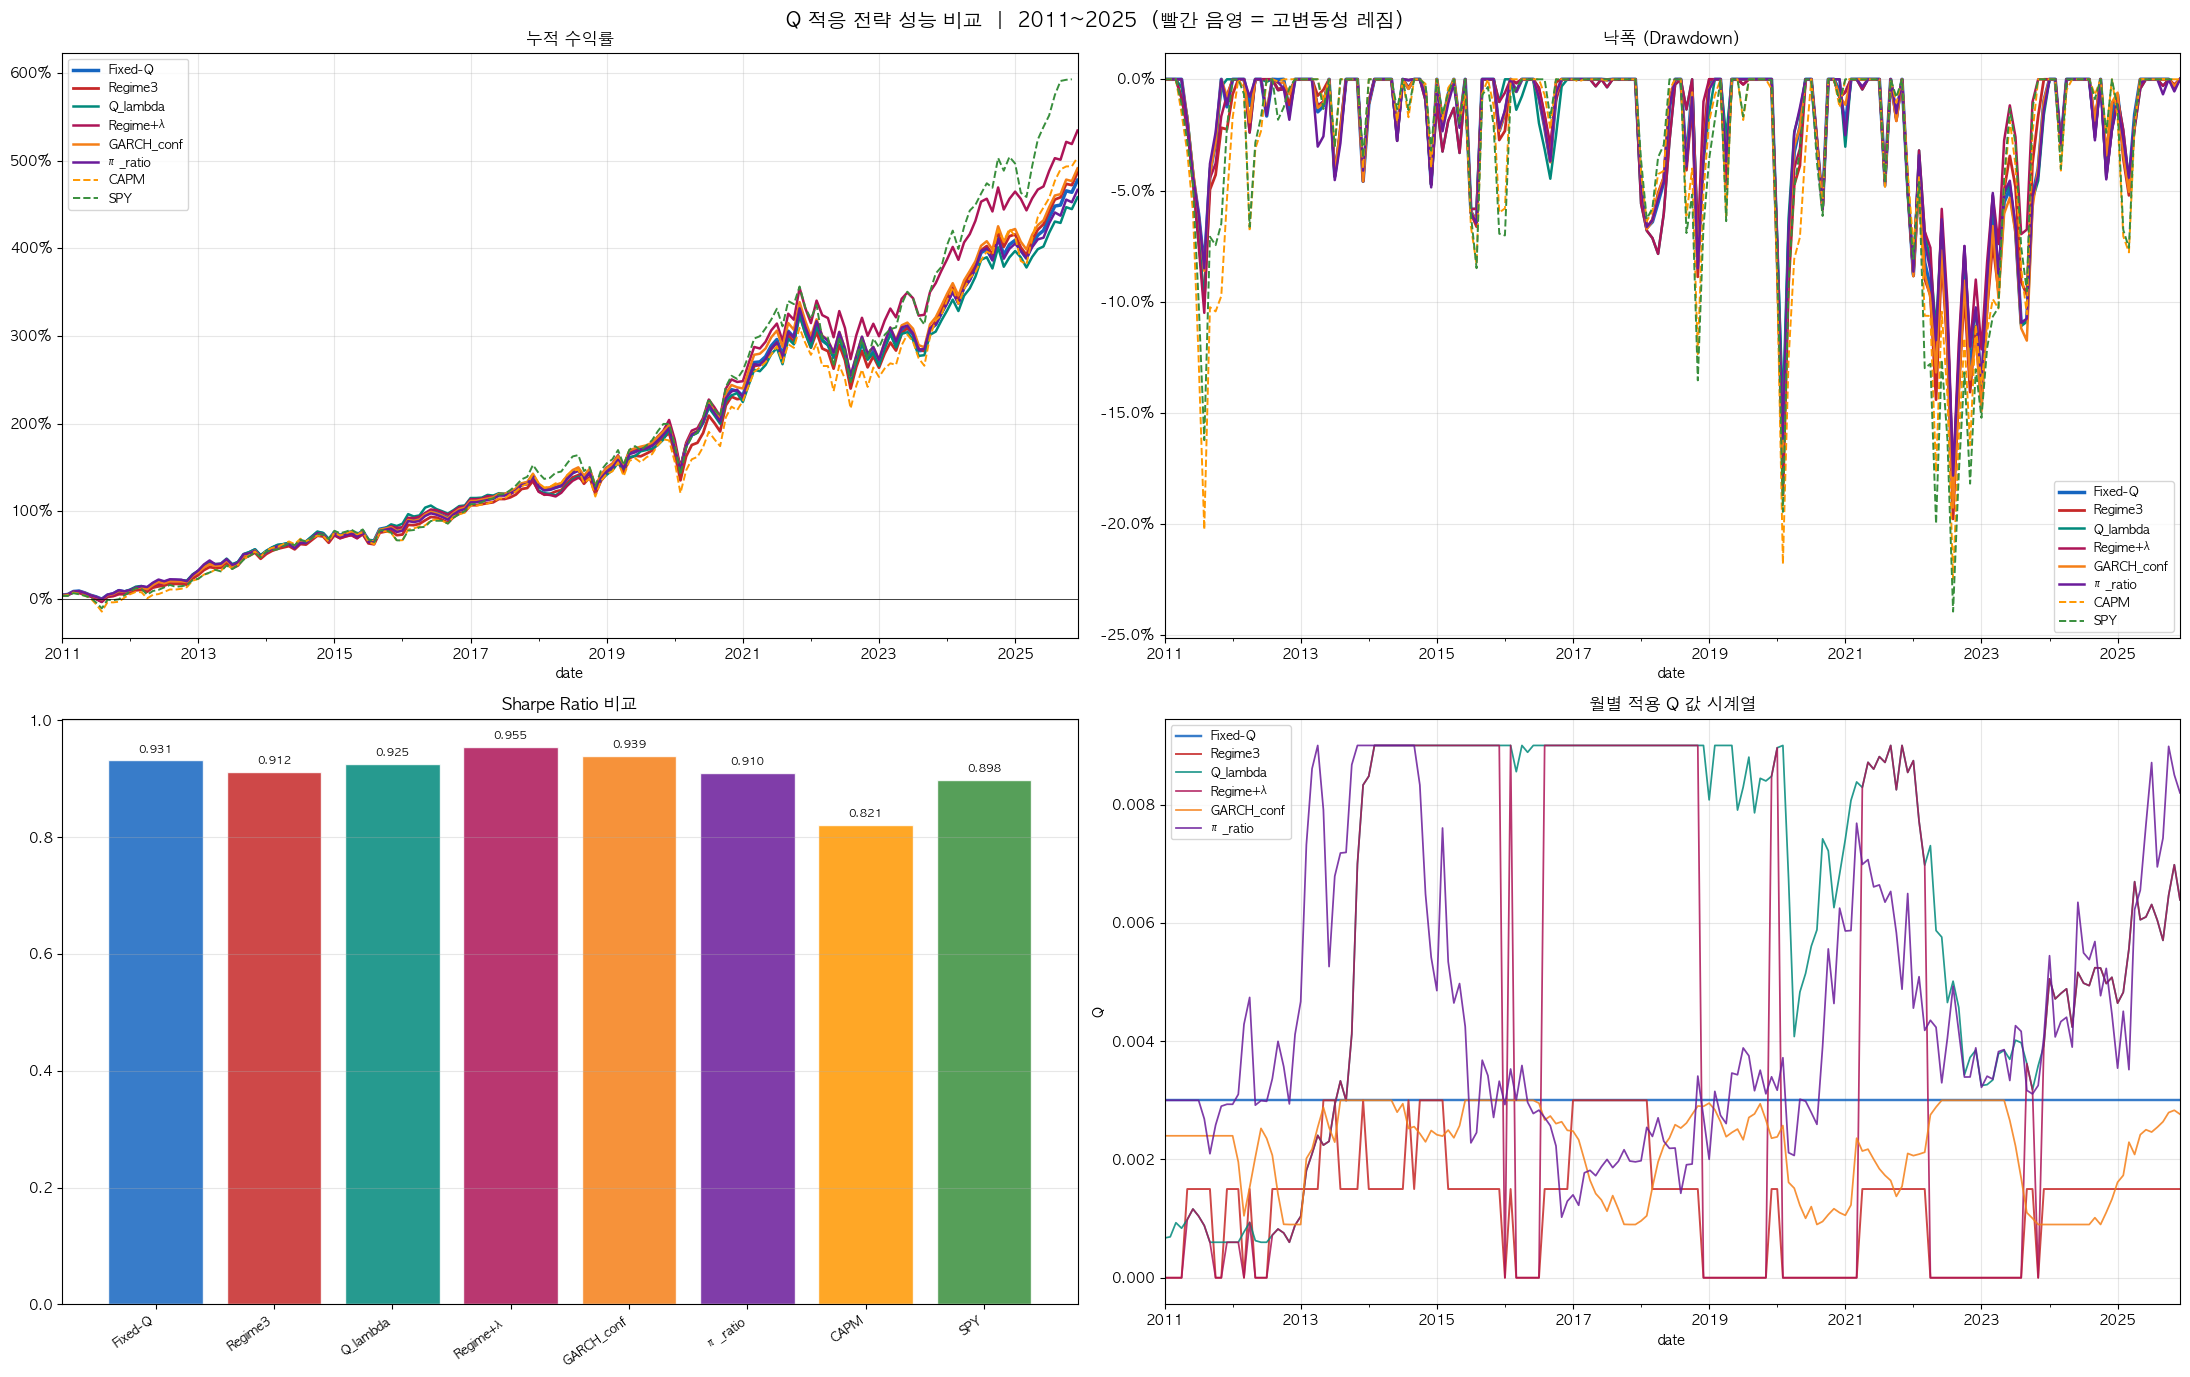

In [6]:
PALETTE = {
    'Fixed-Q':    ('#1565C0', '-',  2.5),
    'Regime3':    ('#C62828', '-',  2.0),
    'Q_lambda':   ('#00897B', '-',  1.8),
    'Regime+λ':   ('#AD1457', '-',  1.8),
    'GARCH_conf': ('#F57F17', '-',  1.8),
    'π_ratio':    ('#6A1B9A', '-',  1.8),
    'CAPM':       ('#FF9800', '--', 1.4),
    'SPY':        ('#388E3C', '--', 1.4),
}

# 고변동성 음영
high_vol_dates = q_df.index[q_df['regime'] == '고변동성']

fig, axes = plt.subplots(2, 2, figsize=(22, 14))
fig.suptitle('Q 적응 전략 성능 비교  |  2011~2025  (빨간 음영 = 고변동성 레짐)',
             fontsize=14, fontweight='bold')

# ① 누적 수익률
ax = axes[0, 0]
shade_high_vol(ax, high_vol_dates)
for name in STRAT_NAMES:
    if name not in ret_all:
        continue
    color, ls, lw = PALETTE[name]
    ((1 + ret_all[name]).cumprod() - 1).plot(
        ax=ax, label=name, color=color, linestyle=ls, linewidth=lw)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3)

# ② 낙폭
ax = axes[0, 1]
shade_high_vol(ax, high_vol_dates)
for name in STRAT_NAMES:
    if name not in ret_all:
        continue
    color, ls, lw = PALETTE[name]
    drawdown(ret_all[name]).plot(
        ax=ax, label=name, color=color, linestyle=ls, linewidth=lw)
ax.set_title('낙폭 (Drawdown)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ③ Sharpe 막대 비교
ax = axes[1, 0]
bl_only = [s for s in STRAT_NAMES if s in stats_df.index]
x_pos   = range(len(bl_only))
sh_vals = [float(stats_df.loc[s, 'Sharpe']) for s in bl_only]
colors  = [PALETTE[s][0] for s in bl_only]
bars    = ax.bar(x_pos, sh_vals, color=colors, alpha=0.85, edgecolor='white')
ax.set_xticks(list(x_pos))
ax.set_xticklabels(bl_only, rotation=35, ha='right', fontsize=9)
ax.set_title('Sharpe Ratio 비교')
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, sh_vals):
    offset = 0.01 if val >= 0 else -0.04
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# ④ 월별 Q 시계열
ax = axes[1, 1]
shade_high_vol(ax, high_vol_dates)
q_strats = ['Fixed-Q', 'Regime3', 'Q_lambda', 'Regime+λ', 'GARCH_conf', 'π_ratio']
for col in q_strats:
    if col not in q_df.columns:
        continue
    color, ls, lw = PALETTE[col]
    q_df[col].plot(ax=ax, label=col, color=color, linestyle=ls,
                   linewidth=max(lw * 0.7, 0.8), alpha=0.85)
ax.set_title('월별 적용 Q 값 시계열')
ax.set_ylabel('Q')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'q_adaptive_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 레짐별 성과 분해

각 레짐에서 어떤 전략이 Fixed-Q 대비 우위인지 확인.

In [7]:
regime_col = q_df['regime']

print('=' * 75)
print('레짐별 Sharpe — Fixed-Q 대비 (+ = 우위, - = 열위)')
print('=' * 75)

for reg in ['저변동성', '중간', '고변동성']:
    mask = regime_col == reg
    n    = mask.sum()
    if n == 0:
        continue
    sub_dates = regime_col[mask].index
    print(f'\n[{reg}]  n={n}개월')
    print(f"  {'전략':15s}  {'Sharpe':>8}  {'vs Fixed-Q':>11}")

    base_sh = None
    for name in STRAT_NAMES:
        if name not in ret_all:
            continue
        sub_ret = ret_all[name].reindex(sub_dates).dropna()
        rf_sub  = rf_monthly.reindex(sub_ret.index).fillna(0)
        exc     = sub_ret - rf_sub
        sh      = (exc.mean() / exc.std() * ANN
                   if exc.std() > 0 else np.nan)
        if name == 'Fixed-Q':
            base_sh = sh
        diff_str = (f'{sh - base_sh:>+11.3f}'
                    if base_sh is not None and not np.isnan(sh) else '          —')
        print(f'  {name:15s}  {sh:>8.3f}  {diff_str}')

# 전략별 최강 레짐 요약
print('\n' + '=' * 75)
print('각 전략이 Fixed-Q 대비 가장 우위인 레짐')
print('=' * 75)

for name in STRAT_NAMES:
    if name in ('Fixed-Q', 'CAPM', 'SPY') or name not in ret_all:
        continue
    best_diff = -np.inf
    best_reg  = None
    for reg in ['저변동성', '중간', '고변동성']:
        mask    = regime_col == reg
        sub_dates = regime_col[mask].index
        r_strat = ret_all[name].reindex(sub_dates).dropna()
        r_fixed = ret_all['Fixed-Q'].reindex(sub_dates).dropna()
        rf_sub  = rf_monthly.reindex(r_strat.index).fillna(0)
        sh_s    = (r_strat - rf_sub).mean() / (r_strat - rf_sub).std() * ANN
        sh_f    = (r_fixed - rf_sub).mean() / (r_fixed - rf_sub).std() * ANN
        diff    = sh_s - sh_f
        if diff > best_diff:
            best_diff = diff
            best_reg  = reg
    print(f'  {name:15s}: {best_reg} 레짐에서 최대 우위 ({best_diff:+.3f})')

레짐별 Sharpe — Fixed-Q 대비 (+ = 우위, - = 열위)

[저변동성]  n=24개월
  전략                 Sharpe   vs Fixed-Q
  Fixed-Q             0.262       +0.000
  Regime3             0.262       +0.000
  Q_lambda            0.089       -0.173
  Regime+λ            0.089       -0.173
  GARCH_conf          0.338       +0.076
  π_ratio             0.308       +0.046
  CAPM                0.502       +0.240
  SPY                 0.796       +0.534

[중간]  n=96개월
  전략                 Sharpe   vs Fixed-Q
  Fixed-Q             0.973       +0.000
  Regime3             0.947       -0.025
  Q_lambda            1.071       +0.099
  Regime+λ            1.071       +0.099
  GARCH_conf          0.958       -0.015
  π_ratio             0.925       -0.047
  CAPM                0.733       -0.240
  SPY                 0.755       -0.217

[고변동성]  n=60개월
  전략                 Sharpe   vs Fixed-Q
  Fixed-Q             1.085       +0.000
  Regime3             1.066       -0.019
  Q_lambda            0.980       -0.105
  Regime+λ 

# 결과 저장 및 최종 요약

In [8]:
# 결과 저장
pd.DataFrame(ret_all).to_csv(OUT_DIR / 'q_adaptive_returns.csv')
q_df.to_csv(OUT_DIR / 'q_adaptive_log.csv')

print('저장 완료:')
for f in sorted(OUT_DIR.glob('*')):
    print(f'  {f.name}')

print()
print('=' * 65)
print('최종 요약 — Sharpe / MDD')
print('=' * 65)
print(f"  {'전략':15s}  {'Sharpe':>8}  {'MDD':>9}")
for name in STRAT_NAMES:
    if name in stats_df.index:
        s  = stats_df.loc[name, 'Sharpe']
        m  = stats_df.loc[name, 'MDD']
        mk = '★' if name == best_sh else ' '
        print(f'{mk} {name:15s}  {s:>8.3f}  {m:>9.2%}')

print()
print(f'★ Sharpe 1위: {best_sh}  ({stats_df.loc[best_sh, "Sharpe"]:.3f})')
print(f'★ MDD   최소: {best_mdd}  ({stats_df.loc[best_mdd, "MDD"]:.2%})')

저장 완료:
  q_adaptive_comparison.png
  q_adaptive_log.csv
  q_adaptive_returns.csv
  q_adaptive_stats.csv
  regime_garch_conf.png

최종 요약 — Sharpe / MDD
  전략                 Sharpe        MDD
  Fixed-Q             0.931    -18.81%
  Regime3             0.912    -19.76%
  Q_lambda            0.925    -17.92%
★ Regime+λ            0.955    -18.05%
  GARCH_conf          0.939    -19.25%
  π_ratio             0.910    -17.82%
  CAPM                0.821    -22.46%
  SPY                 0.898    -23.93%

★ Sharpe 1위: Regime+λ  (0.955)
★ MDD   최소: π_ratio  (-17.82%)
